# 图论

## 1. NetworkX 库

### 1.1 图的生成
+ Graph(): 无向图
+ DiGraph(): 有向图
+ MultiGraph(): 多重无向图
+ MultiDiGraph(): 多重有向图

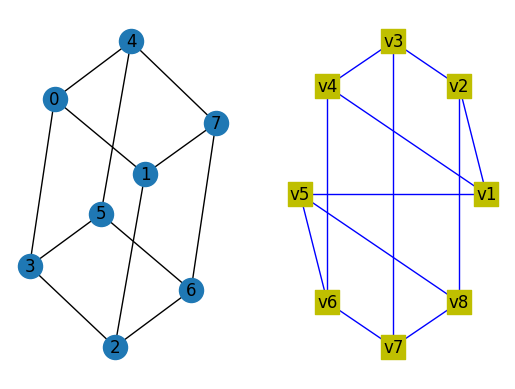

In [1]:
import networkx as nx
import numpy as np
import pylab as plt

'''
nx.draw:
pos: 节点的布局
    - circular_layout(G): 环形布局
    - random_layout(G): 随机布局
    - shell_layout(G): 螺旋布局
    - spring_layout(G): Fruchterman-Reingold 布局
    - spectral_layout(G): 谱布局（根据拉普拉斯特征向量排列节点）
'''
graph = nx.cubical_graph()      # 立方体图
plt.subplot(121)
nx.draw(graph, with_labels=True)
plt.subplot(122)
labels = dict(zip(range(8), [f"v{i}" for i in range(1, 9)]))
nx.draw(graph, pos=nx.circular_layout(graph), labels=labels, node_color='y', node_shape='s', edge_color='b')
plt.show()

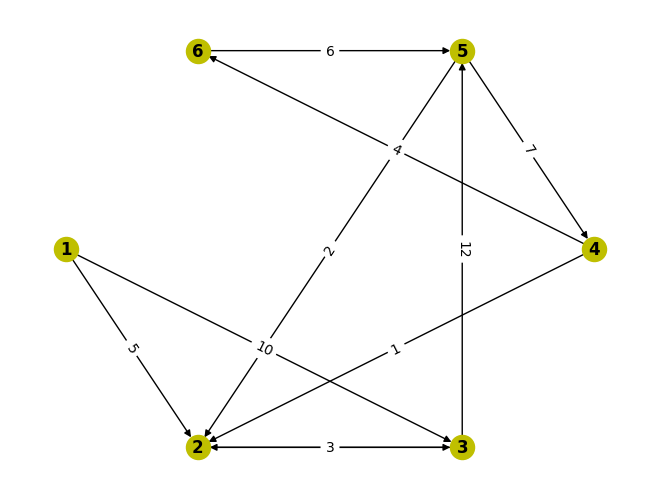

In [2]:
graph = nx.DiGraph()
graph.add_nodes_from(range(1, 7))   # 添加节点
graph.add_weighted_edges_from([(1, 2, 5), (1, 3, 10), (2, 3, 8), (3, 2, 3), (3, 5, 12), (4, 2, 1), (4, 6, 4), (5, 2, 2), (5, 4, 7), (6, 5, 6)])     # 添加边
pos = nx.shell_layout(graph)
nx.draw(graph, pos=pos, with_labels=True, font_weight='bold', node_color='y')
nx.draw_networkx_edge_labels(graph, pos=pos, edge_labels=nx.get_edge_attributes(graph, "weight"))
plt.show()

In [3]:
# 导出邻接矩阵
w = nx.to_numpy_array(graph)
print(w)

[[ 0.  5. 10.  0.  0.  0.]
 [ 0.  0.  8.  0.  0.  0.]
 [ 0.  3.  0.  0. 12.  0.]
 [ 0.  1.  0.  0.  0.  4.]
 [ 0.  2.  0.  7.  0.  0.]
 [ 0.  0.  0.  0.  6.  0.]]


### 1.2 基本算法

In [4]:
path = nx.dijkstra_path(graph, source=1, target=5, weight="weight")
print(path)

[1, 3, 5]


In [5]:
length = nx.dijkstra_path_length(graph, source=1, target=5, weight="weight")
print(length)

22


## 2. 最大流和最小费用问题

### 2.1 最大流问题
1. 基本概念
+ $c_{ij}$: 边 $(v_i, v_j)$ 的容量, $c_{ij} \geq 0$
+ $f_{ij}$: 边 $(v_i, v_j)$ 的流量, $0 \leq f_{ij} \leq c_{ij}$
+ $s$: 源点, $s \in V$
+ $t$: 汇点, $t \in V$
2. 线性规划模型

$\max v$

$ s.t.\left\{ \begin{array}{ll} \sum\limits_{j: (v_s, v_j)\in E}f_{sj}=v, & \\ \sum\limits_{j: (v_i, v_j)\in E}f_{ij} - \sum\limits_{k: (v_k, v_i)\in E}f_{ki}=0, & i \neq s, t \\ \sum\limits_{j: (v_j, v_t)\in E}f_{jt}=v, & \\0 \leq f_{ij} \leq c_{ij}, & \forall (v_i, v_j) \in E \end{array} \right. $

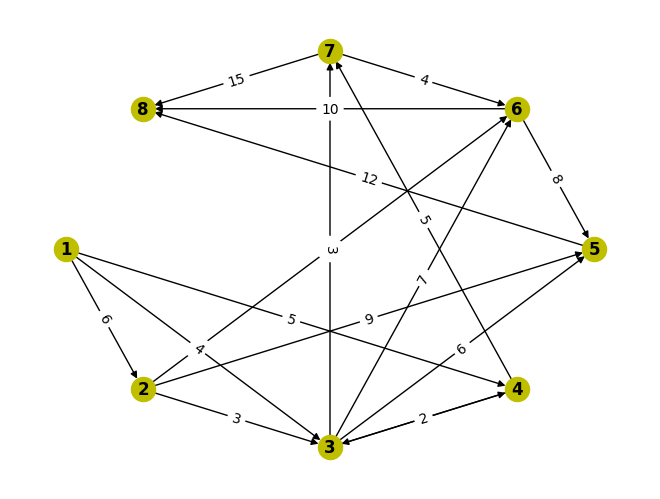

In [6]:
graph = nx.DiGraph()
graph.add_nodes_from(range(1, 9))
E = [(1, 2, 6), (1, 3, 4), (1, 4, 5), (2, 3, 3), (2, 5, 9), (2, 6, 9), (3, 4, 5), (3, 5, 6), (3, 6, 7), (3, 7, 3), (4, 3, 2), (4, 7, 5), (5, 8, 12), (6, 5, 8), (6, 8, 10), (7, 6, 4), (7, 8, 15)]
graph.add_weighted_edges_from(E, weight="capacity")
pos = nx.shell_layout(graph)
nx.draw(graph, pos=pos, with_labels=True, font_weight='bold', node_color='y')
capacity = nx.get_edge_attributes(graph, "capacity")
nx.draw_networkx_edge_labels(graph, pos=pos, edge_labels=capacity)
plt.show()

In [7]:
value, flow_dict = nx.maximum_flow(graph, 1, 8)
print(f"最大流量: {value}")
print(flow_dict)
n = len(flow_dict)
adjacent = np.zeros((n, n), dtype=int)
for i, adj in flow_dict.items():
    for j, weight in adj.items():
        adjacent[i - 1][j - 1] = weight
print(adjacent)

最大流量: 15
{1: {2: 6, 3: 4, 4: 5}, 2: {3: 0, 5: 6, 6: 0}, 3: {4: 0, 5: 4, 6: 0, 7: 0}, 4: {3: 0, 7: 5}, 5: {8: 10}, 6: {5: 0, 8: 0}, 7: {6: 0, 8: 5}, 8: {}}
[[ 0  6  4  5  0  0  0  0]
 [ 0  0  0  0  6  0  0  0]
 [ 0  0  0  0  4  0  0  0]
 [ 0  0  0  0  0  0  5  0]
 [ 0  0  0  0  0  0  0 10]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  5]
 [ 0  0  0  0  0  0  0  0]]


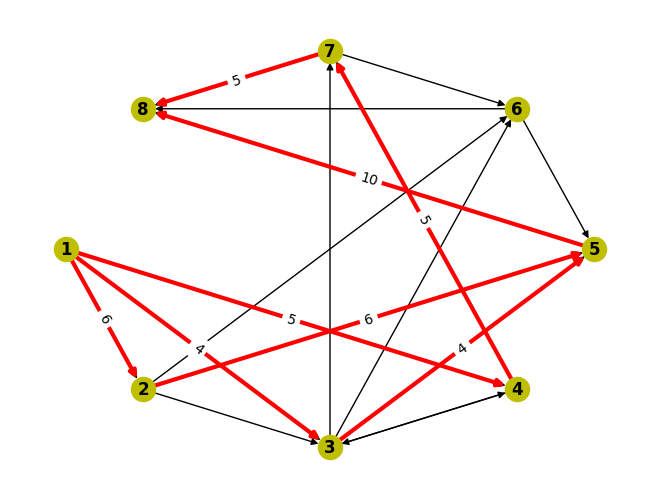

In [8]:
ii, jj = np.nonzero(adjacent)
edge_list = list(zip(ii + 1, jj + 1))
nx.draw(graph, pos=pos, with_labels=True, font_weight='bold', node_color='y')
nx.draw_networkx_edges(graph, pos=pos, edgelist=edge_list, edge_color='r', width=3)
labels = {}
for edge in edge_list:
    labels[edge] = adjacent[edge[0] - 1][edge[1] - 1]
nx.draw_networkx_edge_labels(graph, pos=pos, edge_labels=labels)
plt.show()

### 2.2 最小费用流问题
1. 基本概念
+ 在最大流问题的基础上, 假设每条边 $(v_i, v_j)$ 都有一个单位的费用 $b_{ij}$
2. 线性规划模型

$\min \sum\limits_{(v_i, v_j)\in E}b_{ij}f_{ij}$

$s.t. \left\{ \begin{array}{ll} \sum\limits_{j: (v_s, v_j)\in E}f_{sj}=v, & \\ \sum\limits_{j: (v_i, v_j)\in E}f_{ij} - \sum\limits_{k: (v_k, v_i)\in E}f_{ki}=0, & i \neq s, t \\ \sum\limits_{j: (v_j, v_t)\in E}f_{jt}=v, & \\0 \leq f_{ij} \leq c_{ij}, & \forall (v_i, v_j) \in E \end{array} \right. $

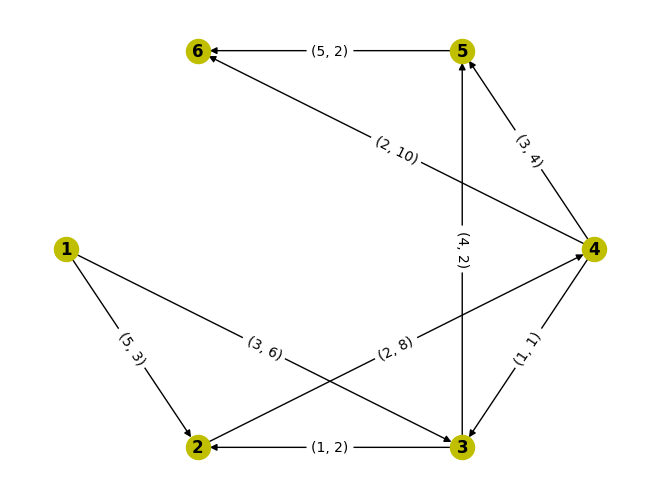

In [9]:
graph = nx.DiGraph()
graph.add_nodes_from(range(1, 7))
E = [(1, 2, 5, 3), (1, 3, 3, 6), (2, 4, 2, 8), (3, 2, 1, 2), (3, 5, 4, 2), (4, 3, 1, 1), (4, 5, 3, 4), (4, 6, 2, 10), (5, 6, 5, 2)]
for i in range(len(E)):
    graph.add_edge(E[i][0], E[i][1], capacity=E[i][2], weight=E[i][3])
capacity = nx.get_edge_attributes(graph, "capacity")
weight = nx.get_edge_attributes(graph, "weight")
pos = nx.shell_layout(graph)
nx.draw(graph, pos=pos, with_labels=True, font_weight='bold', node_color='y')
labels = {}
for edge, cap in capacity.items():
    w = weight[edge]
    labels[edge] = f"({cap}, {w})"
nx.draw_networkx_edge_labels(graph, pos=pos, edge_labels=labels)
plt.show()

In [10]:
max_flow = nx.max_flow_min_cost(graph, 1, 6)
min_cost = nx.cost_of_flow(graph, max_flow)
print(f"最小费用: {min_cost}")
nodes = list(graph.nodes())
n = len(nodes)
adjacent = np.zeros((n, n), dtype=int)
for i, adj in max_flow.items():
    for j, flow in adj.items():
        adjacent[nodes.index(i)][nodes.index(j)] = flow
print(f"最大流量: {np.sum(adjacent[:, -1])}")
print(adjacent)

最小费用: 63
最大流量: 5
[[0 2 3 0 0 0]
 [0 0 0 2 0 0]
 [0 0 0 0 4 0]
 [0 0 1 0 1 0]
 [0 0 0 0 0 5]
 [0 0 0 0 0 0]]


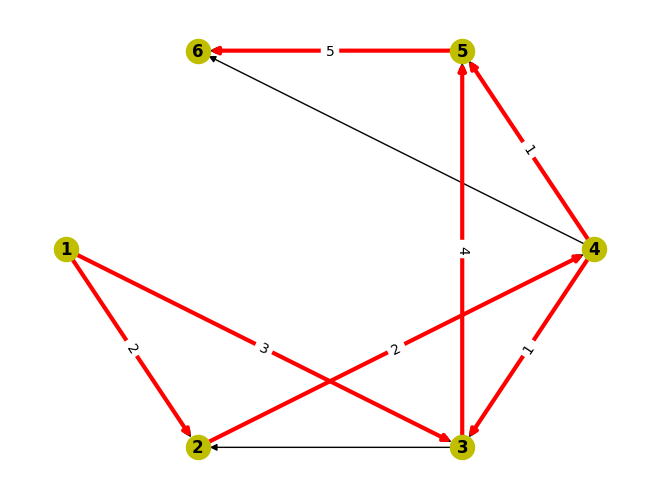

In [11]:
ii, jj = np.nonzero(adjacent)
edge_list = list(zip(ii + 1, jj + 1))
nx.draw(graph, pos=pos, with_labels=True, font_weight='bold', node_color='y')
nx.draw_networkx_edges(graph, pos=pos, edgelist=edge_list, edge_color='r', width=3)
labels = {}
for edge in edge_list:
    labels[edge] = adjacent[edge[0] - 1][edge[1] - 1]
nx.draw_networkx_edge_labels(graph, pos=pos, edge_labels=labels)
plt.show()

## 3. 关键路径

### 3.1 计划网络图
1. 基本概念
+ $x_i$ 是事件 $i$ 的开始时间, 1 $\leq i \leq n$
+ $t_{ij}$ 是活动 $(i,j)$ 的持续时间
2. 规划问题形式

$\min \sum\limits_{i=1}^n x_i$

$s.t. \left\{ \begin{array}{ll} x_j \geq x_i + t_{ij}, & \forall\; (i,j) \in E,\;i,j \in V \\ x_i \geq 0, & \forall \; i \in V \end{array} \right. $

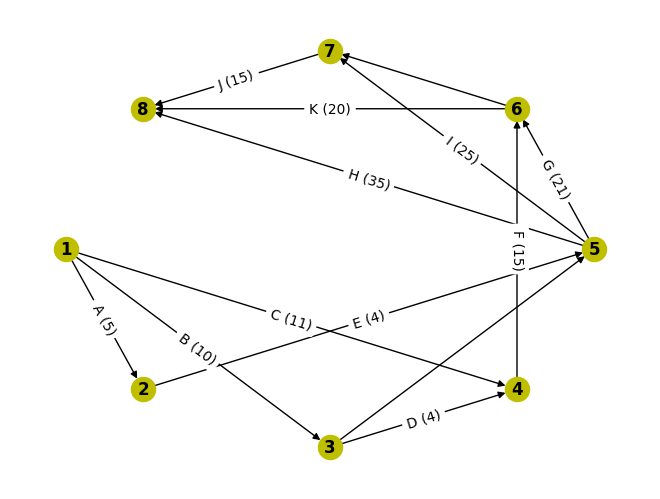

In [12]:
graph = nx.DiGraph()
graph.add_nodes_from(range(1, 9))
E = [(1, 2, 'A', 5), (1, 3, 'B', 10), (1, 4, 'C', 11), (3, 4, 'D', 4), (2, 5, 'E', 4), (3, 5, '', 0), (4, 6, 'F', 15), (5, 6, 'G', 21), (5, 8, 'H', 35), (5, 7, 'I', 25), (7, 8, 'J', 15), (6, 7, '', 0), (6, 8, 'K', 20)]
for i in range(len(E)):
    graph.add_edge(E[i][0], E[i][1], label=E[i][2], weight=E[i][3])
activities = nx.get_edge_attributes(graph, "label")
weight = nx.get_edge_attributes(graph, "weight")
labels = {}
for edge, act in activities.items():
    if act == '':
        continue
    w = weight[edge]
    labels[edge] = f"{act} ({w})"
pos = nx.shell_layout(graph)
nx.draw(graph, pos=pos, with_labels=True, font_weight='bold', node_color='y')
nx.draw_networkx_edge_labels(graph, pos=pos, edge_labels=labels)
plt.show()

In [13]:
import cvxpy as cp

n = 8
x = cp.Variable(n, pos=True)
objective = cp.Minimize(sum(x))
constraints = []
for i in range(len(E)):
    constraints.append(x[E[i][1] - 1] >= x[E[i][0] - 1] + E[i][3])
problem = cp.Problem(objective, constraints)
problem.solve(solver="GLPK_{")
print(f"最优值: {problem.value}")
print(f"最优解: {x.value}")

最优值: 156.0
最优解: [ 0.  5. 10. 14. 10. 31. 35. 51.]


In [15]:
xs = x.value
z = np.zeros(n)     # 最迟开始时间
z[-1] = xs[-1]
for i in range(n - 1, 0, -1):
    z[i - 1] = min([z[e[1] - 1] - e[3] for e in E if e[0] == i])
es = {}     # 最早开始时间
ls = {}     # 最迟开始时间
ef = {}     # 最早结束时间
lf = {}     # 最迟结束时间
for i in range(len(E)):
    es[(E[i][0], E[i][1])] = xs[E[i][0] - 1]
    lf[(E[i][0], E[i][1])] = z[E[i][1] - 1]
    ls[(E[i][0], E[i][1])] = z[E[i][1] - 1] - E[i][3]
    ef[(E[i][0], E[i][1])] = xs[E[i][0] - 1] + E[i][3]
print(es)
print(ls)
print(ef)
print(lf)

{(1, 2): np.float64(0.0), (1, 3): np.float64(0.0), (1, 4): np.float64(0.0), (3, 4): np.float64(10.0), (2, 5): np.float64(5.0), (3, 5): np.float64(10.0), (4, 6): np.float64(14.0), (5, 6): np.float64(10.0), (5, 8): np.float64(10.0), (5, 7): np.float64(10.0), (7, 8): np.float64(35.0), (6, 7): np.float64(31.0), (6, 8): np.float64(31.0)}
{(1, 2): np.float64(1.0), (1, 3): np.float64(0.0), (1, 4): np.float64(5.0), (3, 4): np.float64(12.0), (2, 5): np.float64(6.0), (3, 5): np.float64(10.0), (4, 6): np.float64(16.0), (5, 6): np.float64(10.0), (5, 8): np.float64(16.0), (5, 7): np.float64(11.0), (7, 8): np.float64(36.0), (6, 7): np.float64(36.0), (6, 8): np.float64(31.0)}
{(1, 2): np.float64(5.0), (1, 3): np.float64(10.0), (1, 4): np.float64(11.0), (3, 4): np.float64(14.0), (2, 5): np.float64(9.0), (3, 5): np.float64(10.0), (4, 6): np.float64(29.0), (5, 6): np.float64(31.0), (5, 8): np.float64(45.0), (5, 7): np.float64(35.0), (7, 8): np.float64(50.0), (6, 7): np.float64(31.0), (6, 8): np.float64(

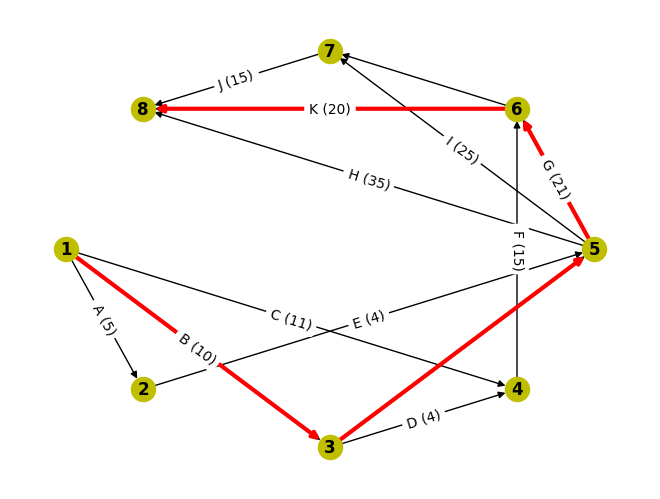

In [16]:
critical_path = []
for edge, e, in es.items():
    if e == ls[edge]:
        critical_path.append(edge)
nx.draw(graph, pos=pos, with_labels=True, font_weight='bold', node_color='y')
nx.draw_networkx_edges(graph, pos=pos, edgelist=critical_path, edge_color='r', width=3)
nx.draw_networkx_edge_labels(graph, pos=pos, edge_labels=labels)
plt.show()